# Regression Metrics — Placement Dataset

Evaluates a **Linear Regression** model trained to predict `package` (LPA) from `cgpa`.

Also evaluates a **Multiple Linear Regression** model on a synthetic dataset with `cgpa` + `iq` → `package`.

Metrics covered: **R², Adjusted R², MSE, MAE, MedAE, RMSE, RMSLE, MAPE**

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error,
    mean_squared_log_error,
    mean_absolute_percentage_error,
)

## 2. Simple Linear Regression: `cgpa` → `package`

In [2]:
df = pd.read_csv('placement.csv')
print('Shape:', df.shape)
df.head()

Shape: (200, 2)


,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [3]:
# Features and target (same as original notebook)
X = df.iloc[:, 0:1]   # cgpa
y = df.iloc[:, -1]    # package

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_true = y_test

print(f'Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')

Train size: 160  |  Test size: 40


### 2.1 R² — coefficient of determination

`R² = 1 - RSS / TSS`  
Ranges 0–1. Higher = better fit. Measures the proportion of variance in `package` explained by `cgpa`.

In [4]:
def R2(y_true, y_pred):
    y_hat = np.mean(y_true)
    rss = np.sum((y_true - y_pred) ** 2)
    tss = np.sum((y_true - y_hat) ** 2)
    return 1 - (rss / tss)

print(f'R² (custom):  {R2(y_true, y_pred):.6f}')
print(f'R² (sklearn): {r2_score(y_true, y_pred):.6f}')

R² (custom):  0.780730
R² (sklearn): 0.780730


### 2.2 Adjusted R²

`Adj R² = 1 - (1 - R²) * (n - 1) / (n - k - 1)`  
Penalizes adding irrelevant features. When k=1, close to R² but slightly lower.

In [5]:
def adjusted_R2(X_test, y_true, y_pred):
    r2 = R2(y_true, y_pred)
    n = y_true.shape[0]
    k = X_test.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

print(f'Adjusted R²: {adjusted_R2(X_test, y_true, y_pred):.6f}')

Adjusted R²: 0.774960


### 2.3 MSE — Mean Squared Error

`MSE = Σ(y - ŷ)² / n`  
Penalizes large errors heavily. Units: LPA².

In [6]:
def mse(y_true, y_pred):
    n = y_true.shape[0]
    return np.sum((y_true - y_pred) ** 2) / n

print(f'MSE (custom):  {mse(y_true, y_pred):.6f}')
print(f'MSE (sklearn): {mean_squared_error(y_true, y_pred):.6f}')

MSE (custom):  0.121292
MSE (sklearn): 0.121292


### 2.4 MAE — Mean Absolute Error

`MAE = Σ|y - ŷ| / n`  
Equal weight to all errors. Less sensitive to outliers than MSE. Units: LPA.

In [7]:
def mae(y_true, y_pred):
    n = y_true.shape[0]
    return np.sum(np.abs(y_true - y_pred)) / n

print(f'MAE (custom):  {mae(y_true, y_pred):.6f}')
print(f'MAE (sklearn): {mean_absolute_error(y_true, y_pred):.6f}')

MAE (custom):  0.288471
MAE (sklearn): 0.288471


### 2.5 MedAE — Median Absolute Error

`MedAE = median(|y - ŷ|)`  
Robust to outliers — uses median instead of mean.

In [8]:
def medae(y_true, y_pred):
    return np.median(np.abs(y_true - y_pred))

print(f'MedAE (custom):  {medae(y_true, y_pred):.6f}')
print(f'MedAE (sklearn): {median_absolute_error(y_true, y_pred):.6f}')

MedAE (custom):  0.251627
MedAE (sklearn): 0.251627


### 2.6 RMSE — Root Mean Squared Error

`RMSE = √MSE`  
Same units as the target (LPA). Penalizes large errors more than MAE.

In [9]:
def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

print(f'RMSE (custom):  {rmse(y_true, y_pred):.6f}')
print(f'RMSE (sklearn): {mean_squared_error(y_true, y_pred) ** 0.5:.6f}')

RMSE (custom):  0.348271
RMSE (sklearn): 0.348271


### 2.7 RMSLE — Root Mean Squared Log Error

`RMSLE = √(Σ(log(y+1) - log(ŷ+1))² / n)`  
Good when relative error matters more than absolute. Requires all predictions > 0.

In [10]:
def rmsle(y_true, y_pred):
    n = y_true.shape[0]
    return np.sqrt(np.sum((np.log(y_true + 1) - np.log(y_pred + 1)) ** 2) / n)

print(f'RMSLE (custom):  {rmsle(y_true, y_pred):.6f}')
print(f'RMSLE (sklearn): {np.sqrt(mean_squared_log_error(y_true, y_pred)):.6f}')

RMSLE (custom):  0.092154
RMSLE (sklearn): 0.092154


### 2.8 MAPE — Mean Absolute Percentage Error

`MAPE = (1/n) * Σ|y - ŷ| / y`  
Intuitive percentage-based error. Unstable when true values are near zero.

In [11]:
def mape(y_true, y_pred):
    n = y_true.shape[0]
    return (1 / n) * np.sum(np.abs((y_true - y_pred) / y_true))

print(f'MAPE (custom):  {mape(y_true, y_pred):.6f}  ({mape(y_true, y_pred)*100:.2f}%)')
print(f'MAPE (sklearn): {mean_absolute_percentage_error(y_true, y_pred):.6f}')

MAPE (custom):  0.106234  (10.62%)
MAPE (sklearn): 0.106234


### 2.9 Summary — Simple Linear Regression

In [12]:
summary_slr = pd.DataFrame([{
    'Model':    'Linear Regression (cgpa → package)',
    'R²':       round(R2(y_true, y_pred), 4),
    'Adj R²':   round(adjusted_R2(X_test, y_true, y_pred), 4),
    'MSE':      round(mse(y_true, y_pred), 6),
    'MAE':      round(mae(y_true, y_pred), 6),
    'MedAE':    round(medae(y_true, y_pred), 6),
    'RMSE':     round(rmse(y_true, y_pred), 6),
    'RMSLE':    round(rmsle(y_true, y_pred), 6),
    'MAPE (%)': round(mape(y_true, y_pred) * 100, 2),
}]).set_index('Model')

summary_slr

,R²,Adj R²,MSE,MAE,MedAE,RMSE,RMSLE,MAPE (%)
Model,,,,,,,,
Linear Regression (cgpa → package),0.7807,0.775,0.121292,0.288471,0.251627,0.348271,0.092154,10.62


### 2.10 Visualisations — Simple Linear Regression

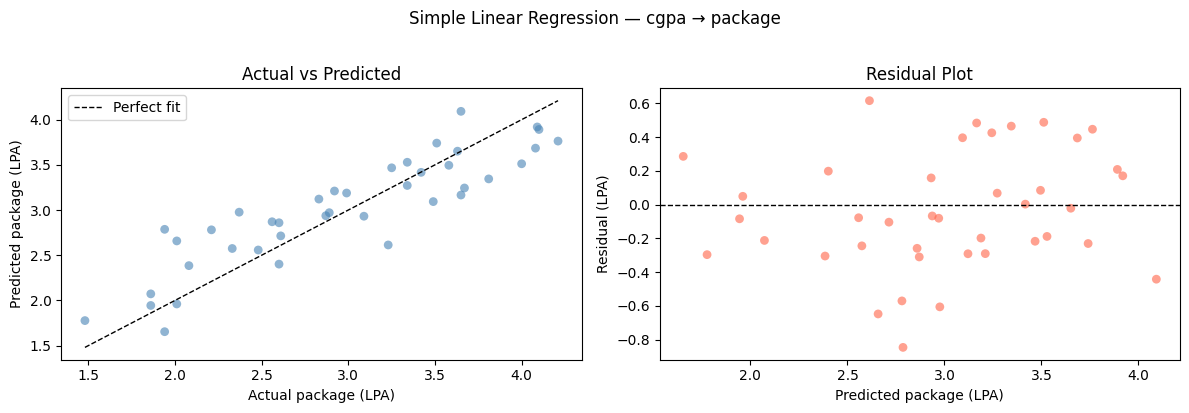

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Actual vs predicted
axes[0].scatter(y_true, y_pred, alpha=0.6, color='steelblue', edgecolors='none', s=40)
lims = [y_true.min(), y_true.max()]
axes[0].plot(lims, lims, 'k--', linewidth=1, label='Perfect fit')
axes[0].set_xlabel('Actual package (LPA)')
axes[0].set_ylabel('Predicted package (LPA)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Residuals
residuals = y_true.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='tomato', edgecolors='none', s=40)
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_xlabel('Predicted package (LPA)')
axes[1].set_ylabel('Residual (LPA)')
axes[1].set_title('Residual Plot')

plt.suptitle('Simple Linear Regression — cgpa → package', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Multiple Linear Regression: `cgpa` + `iq` → `package`

Creates the same synthetic dataset as the original notebook (adding a random IQ column).

In [14]:
# Reproduce the synthetic new_df2 from the original notebook
np.random.seed(0)
new_df2 = df.copy()
new_df2['iq'] = new_df2['package'] + np.random.uniform(-0.5, 0.5, size=len(new_df2))
new_df2 = new_df2[['cgpa', 'iq', 'package']]

print('Shape:', new_df2.shape)
new_df2.sample(5)

Shape: (200, 3)


,cgpa,iq,package
90,7.11,2.478569,2.66
97,5.98,2.360108,2.84
2,7.82,3.352763,3.25
150,6.30,2.379448,2.73
77,8.99,4.220197,4.60


In [15]:
X2 = new_df2.iloc[:, 0:2]   # cgpa, iq
y2 = new_df2.iloc[:, -1]    # package

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=2
)

lr2 = LinearRegression()
lr2.fit(X2_train, y2_train)
y2_pred = lr2.predict(X2_test)
y2_true = y2_test

print(f'Train size: {X2_train.shape[0]}  |  Test size: {X2_test.shape[0]}')

Train size: 160  |  Test size: 40


In [16]:
summary_mlr = pd.DataFrame([{
    'Model':    'Multiple Linear Regression (cgpa + iq → package)',
    'R²':       round(R2(y2_true, y2_pred), 4),
    'Adj R²':   round(adjusted_R2(X2_test, y2_true, y2_pred), 4),
    'MSE':      round(mse(y2_true, y2_pred), 6),
    'MAE':      round(mae(y2_true, y2_pred), 6),
    'MedAE':    round(medae(y2_true, y2_pred), 6),
    'RMSE':     round(rmse(y2_true, y2_pred), 6),
    'RMSLE':    round(rmsle(y2_true, y2_pred), 6),
    'MAPE (%)': round(mape(y2_true, y2_pred) * 100, 2),
}]).set_index('Model')

summary_mlr

,R²,Adj R²,MSE,MAE,MedAE,RMSE,RMSLE,MAPE (%)
Model,,,,,,,,
Multiple Linear Regression (cgpa + iq → package),0.9311,0.9273,0.038131,0.170491,0.162715,0.195272,0.050459,6.04


---
## 4. Side-by-side comparison

In [17]:
comparison = pd.concat([summary_slr, summary_mlr])
comparison.index = ['Simple LR (cgpa)', 'Multiple LR (cgpa + iq)']
comparison

,R²,Adj R²,MSE,MAE,MedAE,RMSE,RMSLE,MAPE (%)
Simple LR (cgpa),0.7807,0.7750,0.121292,0.288471,0.251627,0.348271,0.092154,10.62
Multiple LR (cgpa + iq),0.9311,0.9273,0.038131,0.170491,0.162715,0.195272,0.050459,6.04


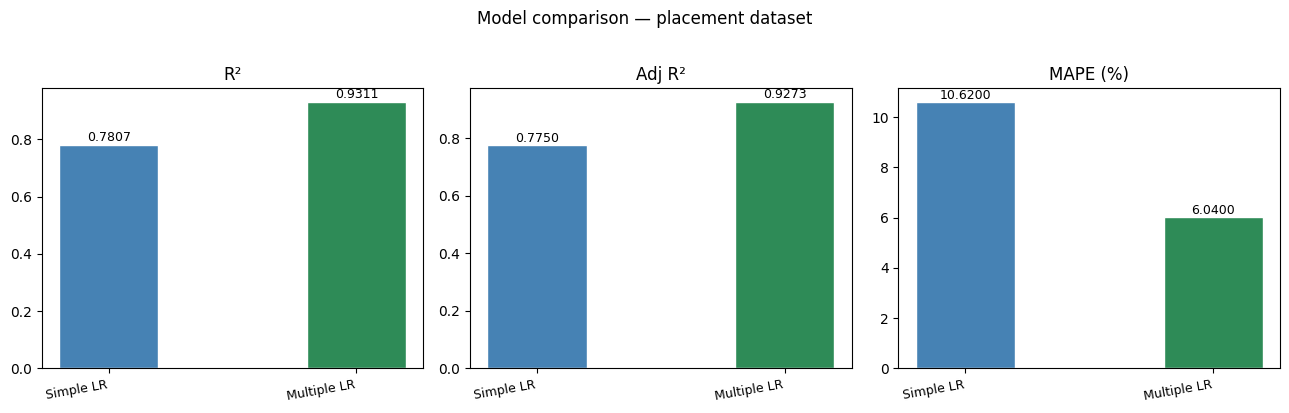

In [18]:
# Bar chart comparing key metrics across both models
metrics_to_plot = ['R²', 'Adj R²', 'MAPE (%)']
colors = ['steelblue', 'seagreen']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(13, 4))

for ax, metric in zip(axes, metrics_to_plot):
    vals = comparison[metric]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='white', width=0.4)
    ax.set_title(metric)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(['Simple LR', 'Multiple LR'], rotation=10, ha='right', fontsize=9)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model comparison — placement dataset', y=1.02)
plt.tight_layout()
plt.show()